# ECON N171: Economic Development
## Lecture 11 — Time Series: Spurious Regression and Cointegration
**Instructor: Rajveer Jat | Summer 2026**

---

## Learning Objectives

1. Understand why standard OLS breaks down with **non-stationary** time series
2. See **spurious regression** in action — two independent series appear strongly correlated
3. Test for **unit roots** using the Augmented Dickey-Fuller (ADF) test
4. Understand **cointegration** — when two non-stationary series share a genuine long-run relationship
5. Apply these tools to real **energy and development** data

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
print('Libraries loaded.')

Libraries loaded.


---
## Part 1: What is a Random Walk?

A **random walk** is a series where each value is the previous value plus random noise:

$$y_t = y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2)$$

This is also called a series with a **unit root** — it has no tendency to return to a mean. Most macroeconomic time series (GDP, prices, energy consumption) behave like random walks.

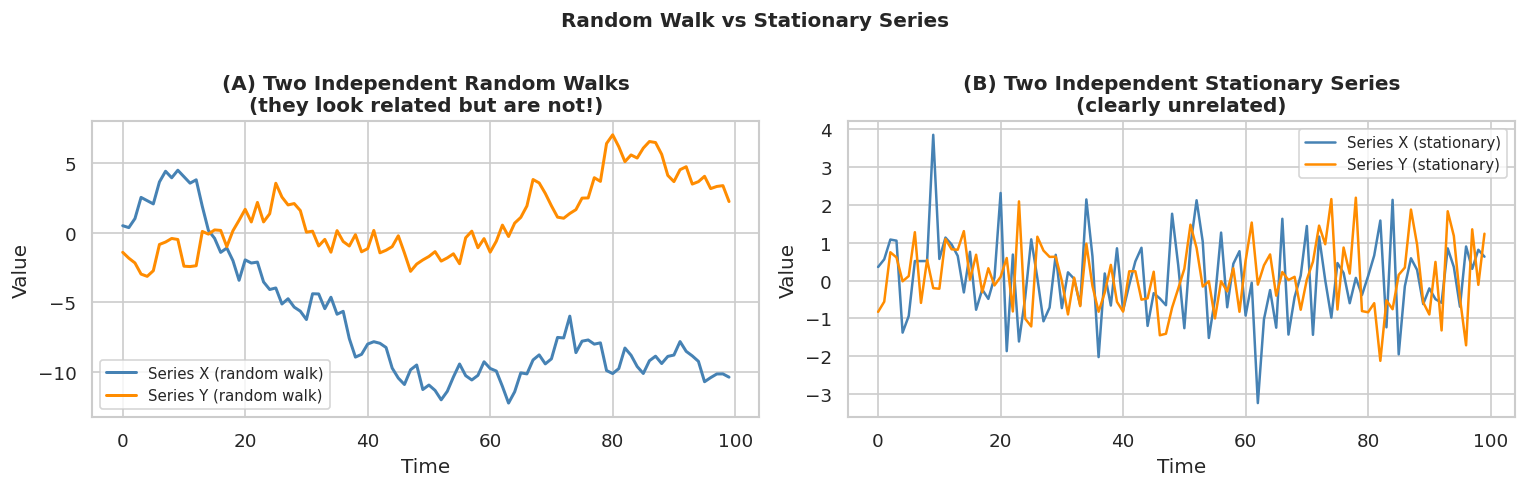

In [2]:
np.random.seed(42)
T = 100   # 100 time periods

# Generate two COMPLETELY INDEPENDENT random walks
rw1 = np.cumsum(np.random.normal(0, 1, T))   # Series X
rw2 = np.cumsum(np.random.normal(0, 1, T))   # Series Y — independent of X!

# Also generate two stationary series (no unit root)
st1 = np.random.normal(0, 1, T)              # Stationary X
st2 = np.random.normal(0, 1, T)              # Stationary Y — independent

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Random walks
axes[0].plot(rw1, color='steelblue', linewidth=1.8, label='Series X (random walk)')
axes[0].plot(rw2, color='darkorange', linewidth=1.8, label='Series Y (random walk)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Value')
axes[0].set_title('(A) Two Independent Random Walks\n(they look related but are not!)', fontweight='bold')
axes[0].legend(fontsize=9)

# Stationary series
axes[1].plot(st1, color='steelblue', linewidth=1.5, label='Series X (stationary)')
axes[1].plot(st2, color='darkorange', linewidth=1.5, label='Series Y (stationary)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Value')
axes[1].set_title('(B) Two Independent Stationary Series\n(clearly unrelated)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Random Walk vs Stationary Series', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 2: Spurious Regression — The Trap

Now regress Y on X for both pairs. The random walks are **independent by construction** — the true R² should be near zero.

Watch what happens.

In [4]:
df_rw = pd.DataFrame({'X': rw1, 'Y': rw2, 't': np.arange(T)})
df_st = pd.DataFrame({'X': st1, 'Y': st2, 't': np.arange(T)})

m_rw = smf.ols('Y ~ X', data=df_rw).fit()
m_st = smf.ols('Y ~ X', data=df_st).fit()

print('=== OLS: Y ~ X for Two INDEPENDENT Series ===')
print()
print(f'{"":35s} {"Random Walk":>12} {"Stationary":>12}')
print('-' * 60)
print(f'{"R-squared":35s} {m_rw.rsquared:>12.3f} {m_st.rsquared:>12.3f}')
print(f'{"Coefficient on X":35s} {m_rw.params["X"]:>12.3f} {m_st.params["X"]:>12.3f}')
print(f'{"t-statistic":35s} {m_rw.tvalues["X"]:>12.3f} {m_st.tvalues["X"]:>12.3f}')
print(f'{"p-value":35s} {m_rw.pvalues["X"]:>12.4f} {m_st.pvalues["X"]:>12.4f}')
print()
print('Both series are INDEPENDENT. True R² = 0. True coefficient = 0.')
print()
if m_rw.pvalues['X'] < 0.05:
    print('🚨 SPURIOUS REGRESSION: Random walk OLS shows SIGNIFICANT result!')
    print(f'   R² = {m_rw.rsquared:.3f} — looks like a great fit. It is completely fake.')
print()
if m_st.pvalues['X'] >= 0.05:
    print('✅ CORRECT: Stationary OLS correctly shows no significant relationship.')

=== OLS: Y ~ X for Two INDEPENDENT Series ===

                                     Random Walk   Stationary
------------------------------------------------------------
R-squared                                  0.135        0.000
Coefficient on X                          -0.207       -0.000
t-statistic                               -3.913       -0.003
p-value                                   0.0002       0.9980

Both series are INDEPENDENT. True R² = 0. True coefficient = 0.

🚨 SPURIOUS REGRESSION: Random walk OLS shows SIGNIFICANT result!
   R² = 0.135 — looks like a great fit. It is completely fake.

✅ CORRECT: Stationary OLS correctly shows no significant relationship.


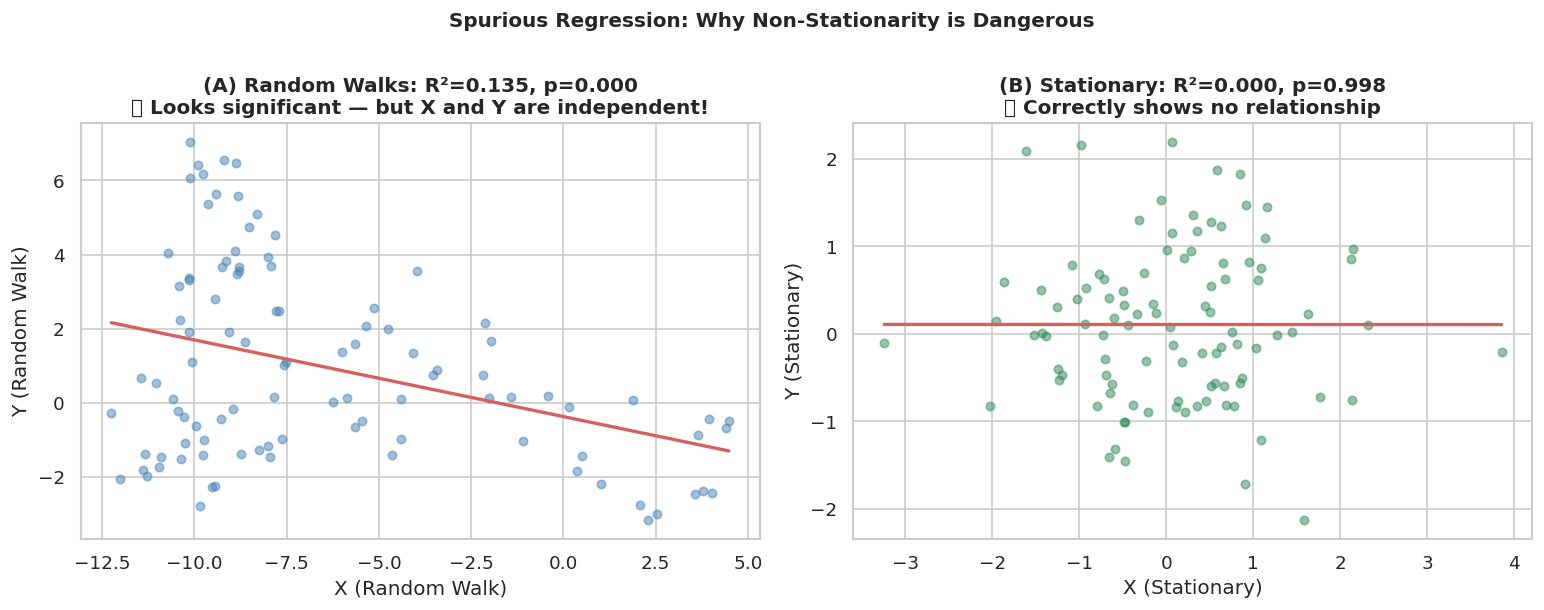

In [5]:
# Visualize the spurious regression
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: random walks
axes[0].scatter(rw1, rw2, alpha=0.5, s=25, color='steelblue')
x_l = np.linspace(rw1.min(), rw1.max(), 100)
axes[0].plot(x_l, m_rw.params['Intercept'] + m_rw.params['X']*x_l, 'r-', linewidth=2)
axes[0].set_xlabel('X (Random Walk)')
axes[0].set_ylabel('Y (Random Walk)')
axes[0].set_title(f'(A) Random Walks: R²={m_rw.rsquared:.3f}, p={m_rw.pvalues["X"]:.3f}\n'
                  '🚨 Looks significant — but X and Y are independent!', fontweight='bold')

# Scatter: stationary
axes[1].scatter(st1, st2, alpha=0.5, s=25, color='seagreen')
x_l2 = np.linspace(st1.min(), st1.max(), 100)
axes[1].plot(x_l2, m_st.params['Intercept'] + m_st.params['X']*x_l2, 'r-', linewidth=2)
axes[1].set_xlabel('X (Stationary)')
axes[1].set_ylabel('Y (Stationary)')
axes[1].set_title(f'(B) Stationary: R²={m_st.rsquared:.3f}, p={m_st.pvalues["X"]:.3f}\n'
                  '✅ Correctly shows no relationship', fontweight='bold')

plt.suptitle('Spurious Regression: Why Non-Stationarity is Dangerous',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 3: How Bad Is It? — Monte Carlo Simulation

Let's repeat this 1,000 times to see how often spurious regression fools us.

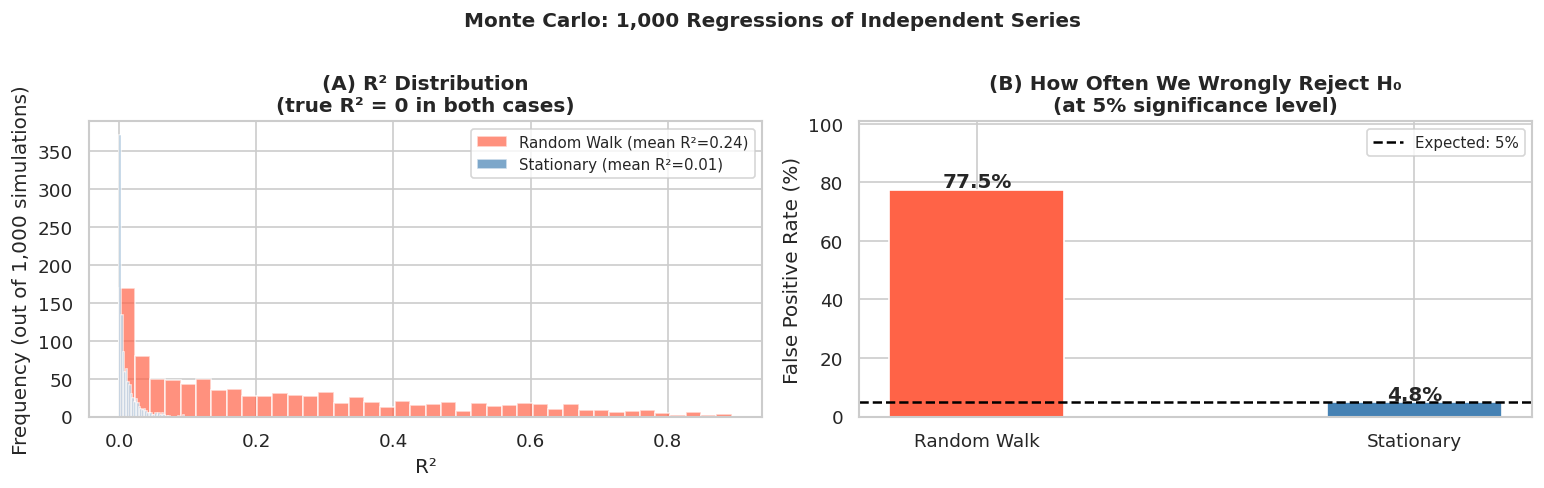

Random walk: false positive rate = 77.5% (should be 5%)
Stationary:  false positive rate = 4.8% (correctly near 5%)

With random walks, standard OLS is unreliable — we reject H0 far too often.


In [6]:
n_sim = 1000
T_sim = 100
r2_rw = []
r2_st = []
pval_rw = []
pval_st = []

for _ in range(n_sim):
    x_rw = np.cumsum(np.random.normal(0, 1, T_sim))
    y_rw = np.cumsum(np.random.normal(0, 1, T_sim))
    x_st = np.random.normal(0, 1, T_sim)
    y_st = np.random.normal(0, 1, T_sim)

    m1 = sm.OLS(y_rw, sm.add_constant(x_rw)).fit()
    m2 = sm.OLS(y_st, sm.add_constant(x_st)).fit()

    r2_rw.append(m1.rsquared)
    r2_st.append(m2.rsquared)
    pval_rw.append(m1.pvalues[1])
    pval_st.append(m2.pvalues[1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# R² distribution
axes[0].hist(r2_rw, bins=40, alpha=0.7, color='tomato',
             edgecolor='white', label=f'Random Walk (mean R²={np.mean(r2_rw):.2f})')
axes[0].hist(r2_st, bins=40, alpha=0.7, color='steelblue',
             edgecolor='white', label=f'Stationary (mean R²={np.mean(r2_st):.2f})')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Frequency (out of 1,000 simulations)')
axes[0].set_title('(A) R² Distribution\n(true R² = 0 in both cases)', fontweight='bold')
axes[0].legend(fontsize=9)

# False positive rate
fp_rw = np.mean(np.array(pval_rw) < 0.05) * 100
fp_st = np.mean(np.array(pval_st) < 0.05) * 100
axes[1].bar(['Random Walk', 'Stationary'], [fp_rw, fp_st],
            color=['tomato', 'steelblue'], edgecolor='white', width=0.4)
axes[1].axhline(5, color='black', linestyle='--', linewidth=1.5, label='Expected: 5%')
for i, v in enumerate([fp_rw, fp_st]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('False Positive Rate (%)')
axes[1].set_title('(B) How Often We Wrongly Reject H₀\n(at 5% significance level)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, max(fp_rw, fp_st) * 1.3)

plt.suptitle('Monte Carlo: 1,000 Regressions of Independent Series',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Random walk: false positive rate = {fp_rw:.1f}% (should be 5%)')
print(f'Stationary:  false positive rate = {fp_st:.1f}% (correctly near 5%)')
print()
print('With random walks, standard OLS is unreliable — we reject H0 far too often.')

---
## Part 4: Testing for Unit Roots — ADF Test

The **Augmented Dickey-Fuller (ADF) test** formally tests whether a series has a unit root.

- $H_0$: series has a unit root (non-stationary)
- $H_1$: series is stationary

If p-value > 0.05: fail to reject $H_0$ → likely non-stationary (random walk)  
If p-value < 0.05: reject $H_0$ → stationary

In [9]:
def adf_test(series, name):
    result = adfuller(pd.Series(series).dropna(), autolag='AIC')
    status = 'NON-STATIONARY' if result[1] > 0.05 else 'STATIONARY'
    print(f'  {name}')
    print(f'    ADF stat: {result[0]:.4f}  |  p-value: {result[1]:.4f}  |  → {status}')
    print()

print('=== ADF Unit Root Tests ===')
print()
adf_test(rw1, 'Random Walk X (should be non-stationary)')
adf_test(rw2, 'Random Walk Y (should be non-stationary)')
adf_test(st1, 'Stationary X (should be stationary)')

print('First differences of random walks:')
adf_test(np.diff(rw1), 'Δ Random Walk X (first difference)')
print('First differences remove the unit root → series becomes stationary.')
print('A series that is non-stationary in levels but stationary in first differences is called I(1).')

=== ADF Unit Root Tests ===

  Random Walk X (should be non-stationary)
    ADF stat: -1.3583  |  p-value: 0.6021  |  → NON-STATIONARY

  Random Walk Y (should be non-stationary)
    ADF stat: -1.8976  |  p-value: 0.3332  |  → NON-STATIONARY

  Stationary X (should be stationary)
    ADF stat: -11.1005  |  p-value: 0.0000  |  → STATIONARY

First differences of random walks:
  Δ Random Walk X (first difference)
    ADF stat: -10.0089  |  p-value: 0.0000  |  → STATIONARY

First differences remove the unit root → series becomes stationary.
A series that is non-stationary in levels but stationary in first differences is called I(1).


---
## Part 5: Cointegration — A Genuine Long-Run Relationship

Two non-stationary series can still have a **genuine relationship** if they share a common trend.

**Example:** Energy consumption and GDP both grow over time (both I(1)). But they may be tied together — higher GDP requires more energy. If they are **cointegrated**, there is a stable long-run relationship between them even though neither is stationary.

**Engle-Granger test:** regress Y on X, test if the residuals are stationary. If residuals are I(0) → cointegrated.

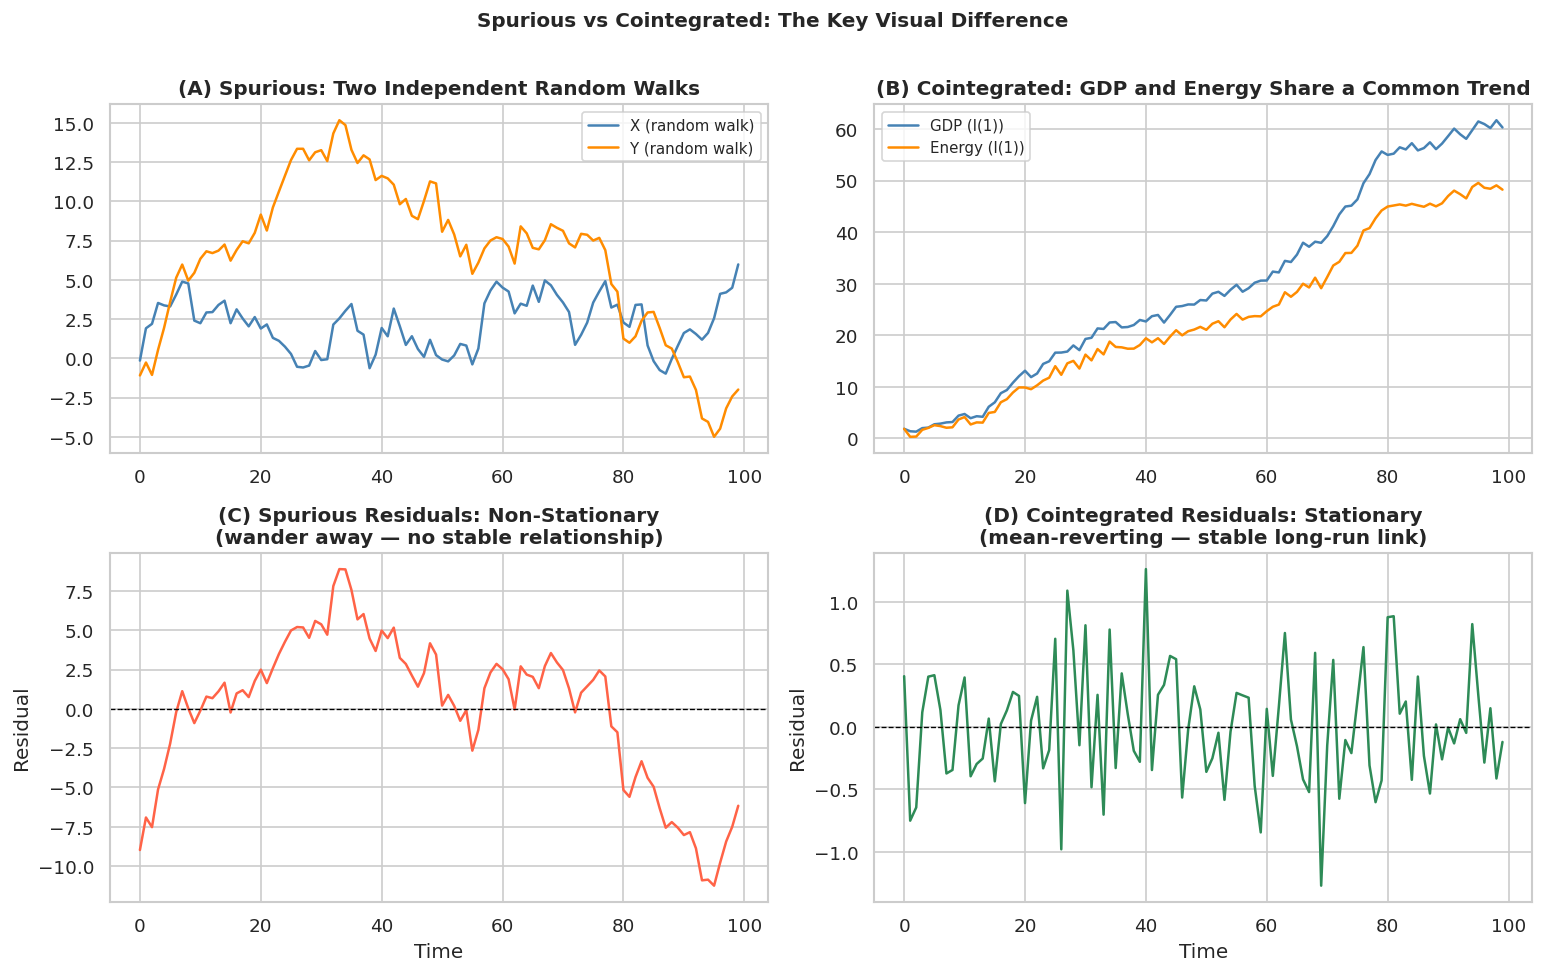

In [10]:
np.random.seed(99)
T = 100

# Case 1: Spurious — two independent random walks
x_spur = np.cumsum(np.random.normal(0, 1, T))
y_spur = np.cumsum(np.random.normal(0, 1, T))  # independent!

# Case 2: Cointegrated — share common trend
# GDP grows as a random walk; energy = 0.8 * GDP + small stationary noise
gdp   = np.cumsum(np.random.normal(0.5, 1, T))   # GDP random walk with drift
energy = 0.8 * gdp + np.random.normal(0, 0.5, T) # energy tracks GDP closely

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Time series plots
axes[0,0].plot(x_spur, color='steelblue', linewidth=1.5, label='X (random walk)')
axes[0,0].plot(y_spur, color='darkorange', linewidth=1.5, label='Y (random walk)')
axes[0,0].set_title('(A) Spurious: Two Independent Random Walks', fontweight='bold')
axes[0,0].legend(fontsize=9)

axes[0,1].plot(gdp,    color='steelblue', linewidth=1.5, label='GDP (I(1))')
axes[0,1].plot(energy, color='darkorange', linewidth=1.5, label='Energy (I(1))')
axes[0,1].set_title('(B) Cointegrated: GDP and Energy Share a Common Trend', fontweight='bold')
axes[0,1].legend(fontsize=9)

# Residuals from OLS
resid_spur = y_spur - (np.polyfit(x_spur, y_spur, 1)[0]*x_spur + np.polyfit(x_spur, y_spur, 1)[1])
resid_coint = energy - (np.polyfit(gdp, energy, 1)[0]*gdp + np.polyfit(gdp, energy, 1)[1])

axes[1,0].plot(resid_spur, color='tomato', linewidth=1.5)
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].set_title('(C) Spurious Residuals: Non-Stationary\n(wander away — no stable relationship)', fontweight='bold')
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Residual')

axes[1,1].plot(resid_coint, color='seagreen', linewidth=1.5)
axes[1,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,1].set_title('(D) Cointegrated Residuals: Stationary\n(mean-reverting — stable long-run link)', fontweight='bold')
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('Residual')

plt.suptitle('Spurious vs Cointegrated: The Key Visual Difference',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Engle-Granger cointegration test
print('=== Engle-Granger Cointegration Test ===')
print()
print('H0: No cointegration (residuals are non-stationary)')
print('Reject H0 → cointegrated → genuine long-run relationship')
print()

# Test 1: spurious pair
_, p_spur, _ = coint(x_spur, y_spur)
print(f'Spurious pair (independent random walks):')
print(f'  p-value = {p_spur:.4f}')
if p_spur > 0.05:
    print('  → FAIL to reject H0: NOT cointegrated ✅ (correct — they are independent)')
print()

# Test 2: cointegrated pair
_, p_coint, _ = coint(gdp, energy)
print(f'Cointegrated pair (GDP and energy):')
print(f'  p-value = {p_coint:.4f}')
if p_coint < 0.05:
    print('  → REJECT H0: COINTEGRATED ✅ (correct — they share a common trend)')

=== Engle-Granger Cointegration Test ===

H0: No cointegration (residuals are non-stationary)
Reject H0 → cointegrated → genuine long-run relationship

Spurious pair (independent random walks):
  p-value = 0.1096
  → FAIL to reject H0: NOT cointegrated ✅ (correct — they are independent)

Cointegrated pair (GDP and energy):
  p-value = 0.0000
  → REJECT H0: COINTEGRATED ✅ (correct — they share a common trend)


---
## Part 6: Real Data — Energy and GDP in Developing Countries

Now let's apply these tools to real World Bank data.

**Question:** Is there a long-run relationship between energy consumption and GDP per capita in developing countries? Does energy use Granger-cause growth, or does growth drive energy demand?

In [12]:
!pip install wbgapi -q
import wbgapi as wb

# Download energy consumption and GDP per capita for India, 1971-2022
# Energy: kg oil equivalent per capita (EG.USE.PCAP.KG.OE)
# GDP per capita: constant 2015 USD (NY.GDP.PCAP.KD)

countries = {'IND': 'India', 'NGA': 'Nigeria', 'VNM': 'Vietnam', 'ETH': 'Ethiopia'}

energy_df = wb.data.DataFrame('EG.USE.PCAP.KG.OE',
                               economy=list(countries.keys()),
                               time=range(1971, 2023),
                               labels=True).reset_index()

gdp_df = wb.data.DataFrame('NY.GDP.PCAP.KD',
                            economy=list(countries.keys()),
                            time=range(1971, 2023),
                            labels=True).reset_index()

def reshape_wb(df, varname):
    df = df.melt(id_vars=['economy','Country'], var_name='year', value_name=varname)
    df['year'] = df['year'].str.replace('YR','').astype(int)
    return df.rename(columns={'economy':'iso','Country':'country'})

energy_long = reshape_wb(energy_df, 'energy_pc')
gdp_long    = reshape_wb(gdp_df,    'gdp_pc')

panel = energy_long.merge(gdp_long, on=['iso','country','year'])
panel['log_energy'] = np.log(panel['energy_pc'])
panel['log_gdp']    = np.log(panel['gdp_pc'])
panel = panel.dropna(subset=['log_energy','log_gdp'])

print('Panel shape:', panel.shape)
panel.head()

Panel shape: (132, 7)


,iso,country,year,energy_pc,gdp_pc,log_energy,log_gdp
76,ETH,Ethiopia,1990,368.247987,267.078135,5.908757,5.587541
77,VNM,Viet Nam,1990,272.780251,687.860316,5.608667,6.533586
78,NGA,Nigeria,1990,287.480712,1577.196166,5.661156,7.363404
79,IND,India,1990,323.595831,537.870270,5.779495,6.287617
80,ETH,Ethiopia,1991,366.903731,237.502455,5.905099,5.470178


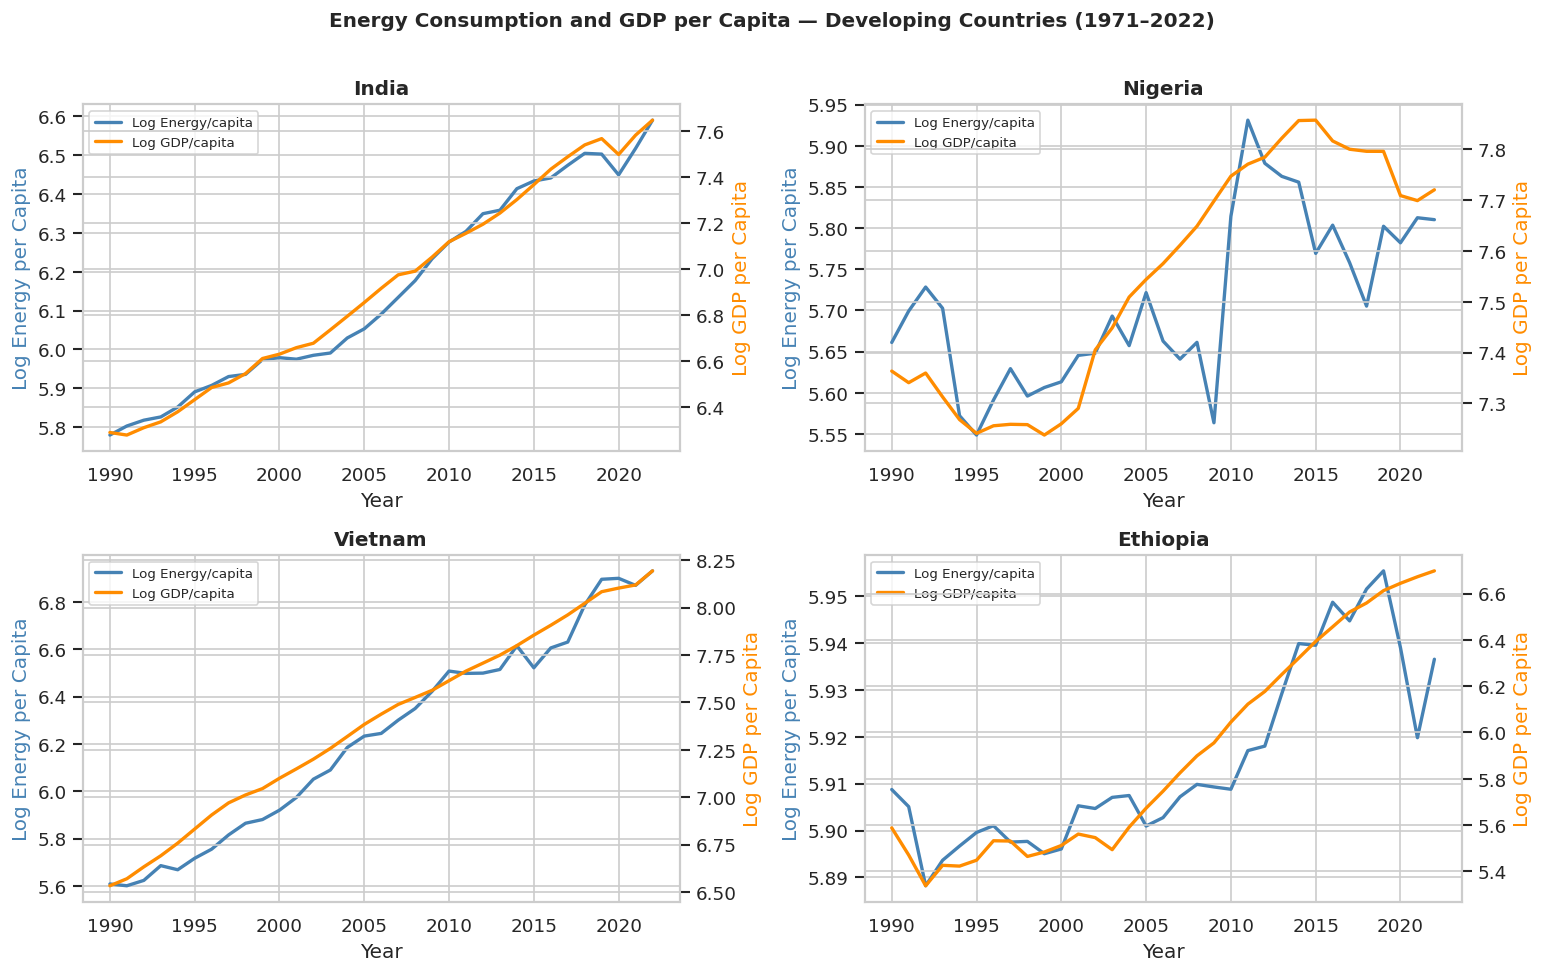

In [13]:
# Plot energy and GDP over time for each country
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (iso, name) in enumerate(countries.items()):
    sub = panel[panel['iso'] == iso].sort_values('year')
    ax  = axes[i]
    ax2 = ax.twinx()

    ax.plot(sub['year'], sub['log_energy'], color='steelblue', linewidth=2, label='Log Energy/capita')
    ax2.plot(sub['year'], sub['log_gdp'],   color='darkorange', linewidth=2, label='Log GDP/capita')

    ax.set_xlabel('Year')
    ax.set_ylabel('Log Energy per Capita', color='steelblue')
    ax2.set_ylabel('Log GDP per Capita',   color='darkorange')
    ax.set_title(f'{name}', fontweight='bold')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.suptitle('Energy Consumption and GDP per Capita — Developing Countries (1971–2022)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# Unit root tests for each country — India as main example
india = panel[panel['iso'] == 'IND'].sort_values('year').dropna()

print('=== Unit Root Tests: India ===')
print()
adf_test(india['log_energy'], 'Log Energy per Capita (levels)')
adf_test(india['log_gdp'],    'Log GDP per Capita (levels)')
adf_test(india['log_energy'].diff().dropna(), 'Δ Log Energy (first difference)')
adf_test(india['log_gdp'].diff().dropna(),    'Δ Log GDP (first difference)')

=== Unit Root Tests: India ===

  Log Energy per Capita (levels)
    ADF stat: 0.5457  |  p-value: 0.9862  |  → NON-STATIONARY

  Log GDP per Capita (levels)
    ADF stat: 0.6508  |  p-value: 0.9888  |  → NON-STATIONARY

  Δ Log Energy (first difference)
    ADF stat: -2.4566  |  p-value: 0.1264  |  → NON-STATIONARY

  Δ Log GDP (first difference)
    ADF stat: -5.6148  |  p-value: 0.0000  |  → STATIONARY



In [15]:
# Cointegration test: India
print('=== Cointegration Test: India — Energy and GDP ===')
print()
_, p_india, _ = coint(india['log_energy'], india['log_gdp'])
print(f'Engle-Granger p-value: {p_india:.4f}')
if p_india < 0.05:
    print('→ COINTEGRATED: Energy and GDP share a long-run relationship in India.')
    print('  A 1% increase in GDP is associated with a stable long-run increase in energy use.')
else:
    print('→ NOT cointegrated at 5% level.')

print()
# For all countries
print('Results across countries:')
print(f'{"Country":<12} {"p-value":>10} {"Cointegrated?":>15}')
print('-' * 40)
for iso, name in countries.items():
    sub = panel[panel['iso'] == iso].sort_values('year').dropna()
    if len(sub) < 20:
        continue
    try:
        _, p, _ = coint(sub['log_energy'], sub['log_gdp'])
        result = 'Yes ✅' if p < 0.05 else 'No'
        print(f'{name:<12} {p:>10.4f} {result:>15}')
    except:
        print(f'{name:<12} {"Error":>10}')

=== Cointegration Test: India — Energy and GDP ===

Engle-Granger p-value: 0.6762
→ NOT cointegrated at 5% level.

Results across countries:
Country         p-value   Cointegrated?
----------------------------------------
India            0.6762              No
Nigeria          0.0463           Yes ✅
Vietnam          0.0660              No
Ethiopia         0.0330           Yes ✅


In [16]:
# Granger Causality: does energy Granger-cause GDP or vice versa?
# Note: Granger causality = predictive causality, not structural causality
# We use first-differenced series (stationary) for Granger test

india_diff = india[['log_energy','log_gdp']].diff().dropna()

print('=== Granger Causality Tests: India ===')
print()
print('H0: X does NOT Granger-cause Y (past X has no predictive power for Y)')
print()

print('Does Energy Granger-cause GDP?')
gc1 = grangercausalitytests(
    india_diff[['log_gdp','log_energy']].values, maxlag=2, verbose=False)
for lag in [1, 2]:
    p = gc1[lag][0]['ssr_ftest'][1]
    print(f'  Lag {lag}: p-value = {p:.4f} {"→ Granger-causes" if p < 0.05 else "→ Does not Granger-cause"}')

print()
print('Does GDP Granger-cause Energy?')
gc2 = grangercausalitytests(
    india_diff[['log_energy','log_gdp']].values, maxlag=2, verbose=False)
for lag in [1, 2]:
    p = gc2[lag][0]['ssr_ftest'][1]
    print(f'  Lag {lag}: p-value = {p:.4f} {"→ Granger-causes" if p < 0.05 else "→ Does not Granger-cause"}')

print()
print('Note: Granger causality means predictive power, not structural causality.')
print('"Energy Granger-causes GDP" means past energy data helps predict future GDP.')

=== Granger Causality Tests: India ===

H0: X does NOT Granger-cause Y (past X has no predictive power for Y)

Does Energy Granger-cause GDP?
  Lag 1: p-value = 0.4519 → Does not Granger-cause
  Lag 2: p-value = 0.6079 → Does not Granger-cause

Does GDP Granger-cause Energy?
  Lag 1: p-value = 0.6635 → Does not Granger-cause
  Lag 2: p-value = 0.5176 → Does not Granger-cause

Note: Granger causality means predictive power, not structural causality.
"Energy Granger-causes GDP" means past energy data helps predict future GDP.


---
## Summary

### The Time Series Toolkit

| Concept | What it is | Python tool |
|---------|-----------|-------------|
| Random walk | Series with unit root — no tendency to mean-revert | `np.cumsum(noise)` |
| Spurious regression | OLS on two independent random walks → fake significance | `smf.ols` |
| ADF test | Formal test for unit root | `adfuller(series)` |
| First difference | Remove unit root → I(0) series | `series.diff()` |
| Cointegration | Two I(1) series with stable long-run relationship | `coint(x, y)` |
| Granger causality | Does X help predict Y? | `grangercausalitytests` |

### Key Rules

1. **Always test for unit roots** before running OLS on time series
2. **Never regress two independent random walks** — you will get spurious results
3. **If both series are I(1)**: test for cointegration before concluding there is a relationship
4. **If cointegrated**: you can regress levels — the long-run relationship is genuine
5. **If not cointegrated**: first-difference both series before running OLS
6. **Granger causality ≠ causality** — it is predictive power, nothing more

### The Energy-Development Connection

Energy consumption and GDP per capita are both I(1) in most developing countries — they trend upward without returning to a mean. If they are cointegrated, it implies a stable long-run relationship: economic growth and energy use move together. This has direct policy implications for climate commitments — can developing countries grow without proportionally increasing energy use?

---
*ECON N171 | Summer 2026*